# Logistic Regression: Predict Diabetes Risk

This notebook performs logistic regression on a dataset with multiple features to predict whether a person is at risk of diabetes. The model is evaluated using accuracy and a confusion matrix.

The notebook includes the required sections: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output. It also includes data cleaning, EDA, feature scaling, feature engineering, and simple model evaluation.

In [10]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

DATA_PATH = "diabetes_risk.csv"
FEATURE_COLS = ["glucose", "bmi", "age"]
TARGET_COL = "diabetes"

if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 220
    glucose = np.round(np.random.uniform(70, 200, n), 2)
    bmi = np.round(np.random.uniform(18, 45, n), 2)
    age = np.random.randint(18, 80, n)

    score = 0.035 * glucose + 0.08 * bmi + 0.02 * age + np.random.normal(0, 0.8, n)
    diabetes = (score > 8.5).astype(int)

    df_sample = pd.DataFrame({
        "glucose": glucose,
        "bmi": bmi,
        "age": age,
        TARGET_COL: diabetes
    })
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Found existing diabetes_risk.csv, will use it

First 5 rows of diabetes_risk.csv:
   glucose    bmi  age  diabetes
0   118.69  35.76   54         0
1   193.59  33.34   55         1
2   165.16  20.53   36         1
3   147.83  27.93   25         1
4    90.28  25.16   65         0


## 1. Problem Statement

Build a logistic regression model to predict diabetes risk from multiple features: glucose, BMI, and age. Evaluate the model using accuracy and a confusion matrix.

## 2. Understanding of Dataset

Load the dataset and inspect its shape, data types, and summary statistics.

In [11]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

print("\nClass Distribution:")
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
   glucose    bmi  age  diabetes
0   118.69  35.76   54         0
1   193.59  33.34   55         1
2   165.16  20.53   36         1
3   147.83  27.93   25         1
4    90.28  25.16   65         0
5    90.28  24.59   62         0
6    77.55  44.27   18         0
7   182.60  28.61   39         0
8   148.14  42.09   69         1
9   162.05  35.04   34         0

Dataset shape: (220, 4)
Samples: 220, Features: 4

Column data types:
glucose     float64
bmi         float64
age           int64
diabetes      int64
dtype: object

Statistical Summary:
          count        mean        std    min      25%      50%       75%  \
glucose   220.0  132.500864  38.318323  70.66  99.3700  134.505  164.9275   
bmi       220.0   31.676136   7.973090  18.29  25.4975   32.225   38.3925   
age       220.0   48.577273  18.486535  18.00  33.0000   48.500   65.2500   
diabetes  220.0    0.413636   0.493608   0.00   0.0000    0.000    1.0000   

             max  
glucose   19

## 3. Data Cleaning

Check for missing values, duplicates, and invalid values.

In [12]:
print("="*60)
print("DATA CLEANING")
print("="*60)

print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    df = df.dropna()

print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"× Removed {dupes} duplicate(s)")
else:
    print("✓ No duplicates found")

print("\n3. Invalid Values Check:")
invalid_glucose = (df["glucose"] <= 0).sum()
invalid_bmi = (df["bmi"] <= 0).sum()
invalid_age = (df["age"] <= 0).sum()
invalid_target = (~df[TARGET_COL].isin([0, 1])).sum()
print(f"Invalid glucose values: {invalid_glucose}")
print(f"Invalid BMI values: {invalid_bmi}")
print(f"Invalid age values: {invalid_age}")
print(f"Invalid target values: {invalid_target}")

df = df[(df["glucose"] > 0) & (df["bmi"] > 0) & (df["age"] > 0)]
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
Missing values per column:
glucose     0
bmi         0
age         0
diabetes    0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Invalid Values Check:
Invalid glucose values: 0
Invalid BMI values: 0
Invalid age values: 0
Invalid target values: 0

Dataset shape after cleaning: (220, 4)


## 4. Exploratory Data Analysis (EDA)

Visualize the relationship between features and the target class.

EXPLORATORY DATA ANALYSIS


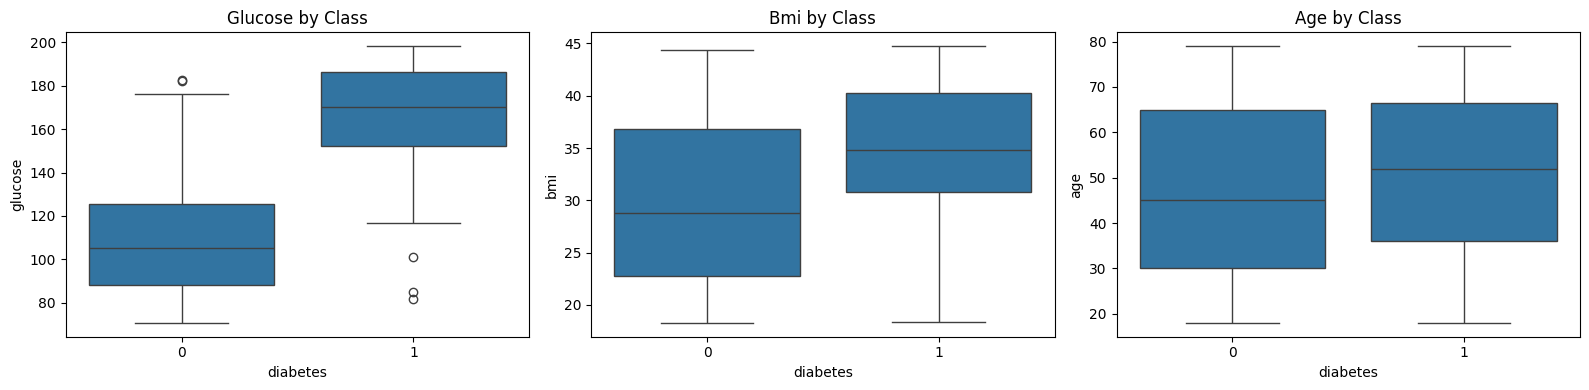

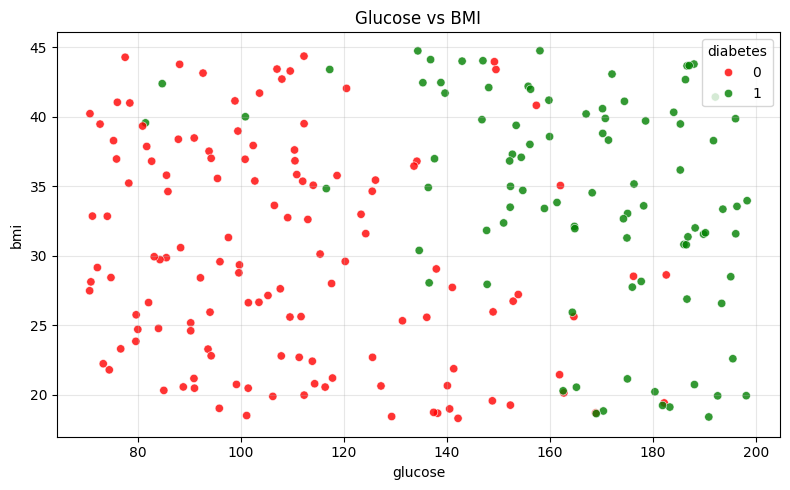


Correlation Matrix:
           glucose       bmi       age  diabetes
glucose   1.000000  0.010230 -0.037475  0.732987
bmi       0.010230  1.000000  0.051478  0.268539
age      -0.037475  0.051478  1.000000  0.095811
diabetes  0.732987  0.268539  0.095811  1.000000


In [13]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col.capitalize()} by Class')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="glucose", y="bmi", hue=TARGET_COL, palette={0: 'red', 1: 'green'}, alpha=0.8)
plt.title('Glucose vs BMI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df[FEATURE_COLS + [TARGET_COL]].corr()
print("\nCorrelation Matrix:")
print(corr)

## 5. Feature Engineering & Scaling

Prepare the feature matrix and scale the inputs.

In [14]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of X:")
print(X[:5])
print("\nFirst 5 rows of scaled X:")
print(X_scaled[:5])

FEATURE ENGINEERING & SCALING
X shape: (220, 3)
y shape: (220,)

First 5 rows of X:
[[118.69  35.76  54.  ]
 [193.59  33.34  55.  ]
 [165.16  20.53  36.  ]
 [147.83  27.93  25.  ]
 [ 90.28  25.16  65.  ]]

First 5 rows of scaled X:
[[-0.36124648  0.51337394  0.29400283]
 [ 1.59788961  0.20916081  0.34821962]
 [ 0.85425491 -1.40115746 -0.68189928]
 [ 0.40095947 -0.47091896 -1.27828391]
 [-1.10435805 -0.81912985  0.89038746]]


## 6. Theory

Logistic regression is used for binary classification. It estimates the probability of the positive class using the sigmoid function.

## 7. Mathematical Representation

- Linear combination: $z = eta_0 + eta_1x_1 + eta_2x_2 + eta_3x_3$
- Sigmoid function: $p = 1 / (1 + e^{-z})$
- Class rule: predict 1 if $p e 0.5$, otherwise predict 0

## 8. Workflow Diagram

WORKFLOW DIAGRAM


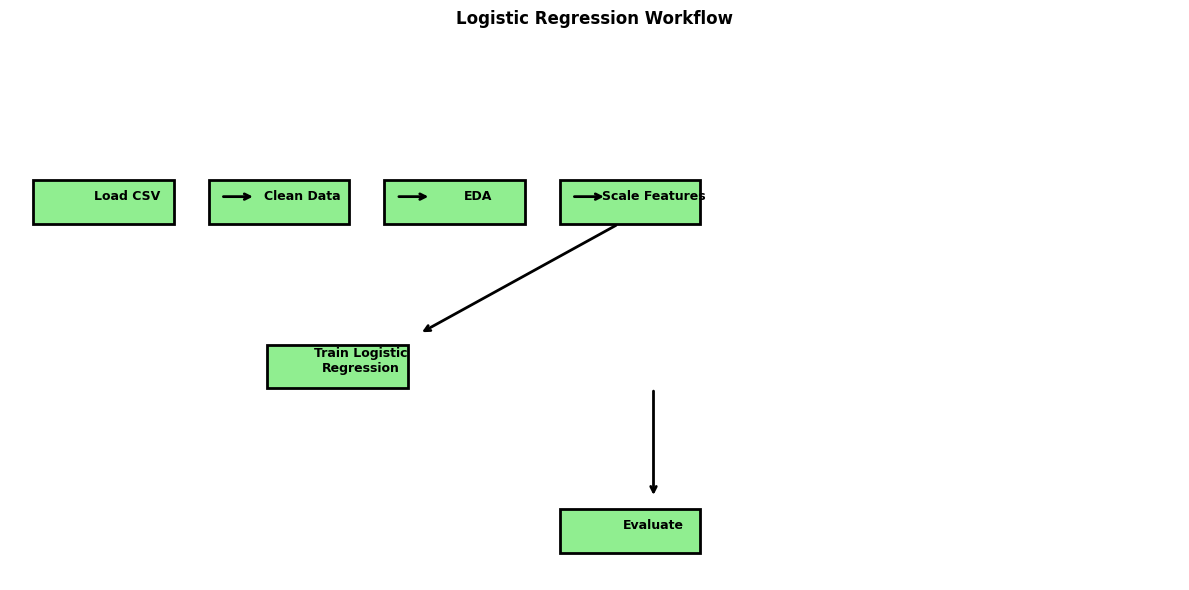

In [15]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Scale Features"),
    (0.3, 0.4, "Train Logistic\nRegression"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Logistic Regression Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load the diabetes risk dataset
2. Clean the data
3. Split the data into features and target
4. Scale the features
5. Split into train and test sets
6. Train a Logistic Regression model
7. Predict classes on test data
8. Evaluate using accuracy and confusion matrix
9. Save the model and scaler
```

## 10. Train-Test Split and Model Training

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Coefficients: {model.coef_[0]}")
print(f"Intercept: {model.intercept_[0]:.4f}")

TRAIN-TEST SPLIT AND MODEL TRAINING
Train size: 176 samples
Test size: 44 samples
Model trained successfully!
Coefficients: [2.64988204 1.15591546 0.67758113]
Intercept: -0.8292


## 11. Evaluation: Accuracy and Confusion Matrix

In [16]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

print("Sample predictions:")
for i in range(min(8, len(y_test))):
    actual = 'Diabetes' if y_test[i] == 1 else 'No Diabetes'
    predicted = 'Diabetes' if y_pred[i] == 1 else 'No Diabetes'
    print(f"Actual: {actual:<12} | Predicted: {predicted:<12}")

MODEL EVALUATION
Accuracy: 0.9091

Confusion Matrix:
[[24  2]
 [ 2 16]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.92      0.92      0.92        26
    Diabetes       0.89      0.89      0.89        18

    accuracy                           0.91        44
   macro avg       0.91      0.91      0.91        44
weighted avg       0.91      0.91      0.91        44

Sample predictions:
Actual: No Diabetes  | Predicted: No Diabetes 
Actual: Diabetes     | Predicted: Diabetes    
Actual: Diabetes     | Predicted: No Diabetes 
Actual: No Diabetes  | Predicted: Diabetes    
Actual: No Diabetes  | Predicted: No Diabetes 
Actual: Diabetes     | Predicted: Diabetes    
Actual: No Diabetes  | Predicted: No Diabetes 
Actual: Diabetes     | Predicted: Diabetes    


## 12. Obtained Output

OBTAINED OUTPUT - VISUALIZATIONS


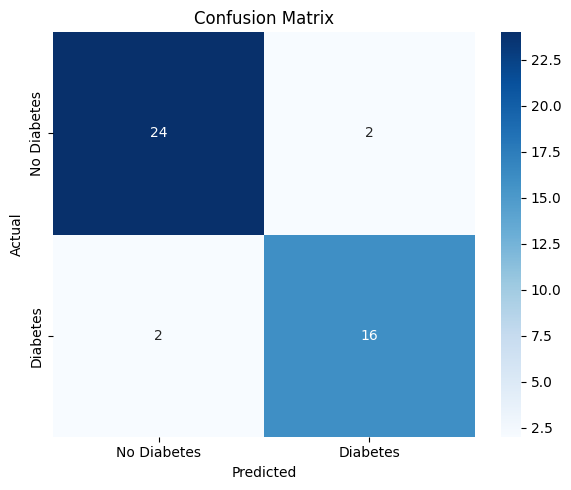

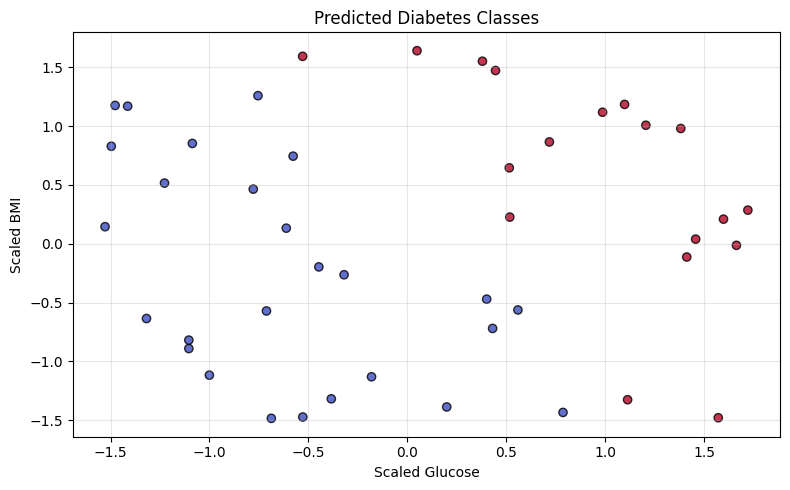


✓ Model and scaler saved successfully

Final Summary:
  Accuracy: 0.9091
  Confusion Matrix:
[[24  2]
 [ 2 16]]


In [17]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.8, edgecolors='black')
plt.xlabel('Scaled Glucose')
plt.ylabel('Scaled BMI')
plt.title('Predicted Diabetes Classes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(model, '7_diabetes_risk_model.joblib')
joblib.dump(scaler, '7_diabetes_risk_scaler.joblib')

print("\n✓ Model and scaler saved successfully")
print("\nFinal Summary:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Confusion Matrix:\n{cm}")